In [6]:
class Quadricula:
    def __init__(self, verbose=False, quadricula=None, escala='25k',
                 IDs=None, gama_data='gama_line_1105', mag_data='mag_line_1105', lito='litologia_1kk'):
        self.escala = escala
        self.IDs = IDs or ['SF23_YA','SF23_YB','SF23_VC','SF23_VD']
        self.gama_data = gama_data
        self.mag_data = mag_data
        self.lito = lito
        self.quadricula = quadricula or {}
        self.verbose = verbose

    def abrir_quadricula(self):
        mc = import_mc(self.escala, self.IDs)
        mc.set_index('id_folha', inplace=True)
        for index, row in tqdm(mc.iterrows()):
            self.quadricula[index] = {'folha': row, 'escala': self.escala}
            if self.verbose:
                print(f' - Folha "{index}" adicionada.')
        if self.verbose:
            print(f'\n {len(self.quadricula)} folhas adicionadas.')
        return self.quadricula

# --- callbacks Tk ---
def get_folhas():
    escala = combo_escala.get()
    mc = import_malha_cartog(escala=escala)  # cuidado: passe por nome
    list_ids = list(mc['id_folha'])
    print(f' - Escala selecionada: {escala}')
    print(f' - Número de folhas: {len(list_ids)}')
    combo_id['values'] = list_ids
    return list_ids

def build_dic():
    escala = combo_escala.get()
    ids = [combo_id.get()] if combo_id.get() else None
    q = Quadricula(verbose=True, escala=escala, IDs=ids)
    quad = q.abrir_quadricula()
    print(quad.keys())

def Update_dic():
    # se quiser apenas atualizar pela seleção atual:
    build_dic()

# catalog.py
from __future__ import annotations
from pathlib import Path
from datetime import datetime
import json
from sqlalchemy import (create_engine, Column, Integer, String, Float,
                        DateTime, Text, UniqueConstraint)
from sqlalchemy.orm import declarative_base, sessionmaker

DB_PATH = Path('/home/database/preditor_terra_catalog.sqlite')
Base = declarative_base()

class RasterProduct(Base):
    __tablename__ = 'raster_products'
    id = Column(Integer, primary_key=True, autoincrement=True)
    sheet_id = Column(String, index=True, nullable=False)        # ex.: SF23_YA_I
    dataset_key = Column(String, index=True, nullable=False)     # ex.: geof_3022_linear
    variable = Column(String, index=True, nullable=False)        # ex.: CTCOR
    path = Column(Text, nullable=False)                          # caminho do GeoTIFF
    epsg = Column(String, nullable=False)
    width = Column(Integer, nullable=False)
    height = Column(Integer, nullable=False)
    res_x = Column(Float, nullable=False)
    res_y = Column(Float, nullable=False)
    transform = Column(Text, nullable=False)                     # json com 6 coef.
    nodata = Column(Float)
    vmin = Column(Float)
    vmax = Column(Float)
    created_at = Column(DateTime, default=datetime.utcnow, nullable=False)
    params_json = Column(Text, nullable=True)                    # algoritmo, psize etc.

    __table_args__ = (
        UniqueConstraint('sheet_id','dataset_key','variable', name='uix_sheet_dataset_var'),
    )

def get_session(db_path: Path = DB_PATH):
    db_path.parent.mkdir(parents=True, exist_ok=True)
    engine = create_engine(f"sqlite:///{db_path}", future=True)
    Base.metadata.create_all(engine)
    return sessionmaker(bind=engine, expire_on_commit=False)()



ModuleNotFoundError: No module named 'sqlalchemy'

In [7]:
# registrar.py
import json
import rasterio
from catalog import get_session, RasterProduct

def register_raster(sheet_id, dataset_key, variable, tiff_path,
                    params: dict | None = None):
    with rasterio.open(tiff_path) as src:
        res_x, res_y = src.res
        width, height = src.width, src.height
        epsg = src.crs.to_epsg() if src.crs else None
        transform = list(src.transform)[:6]  # a,b,c,d,e,f
        nodata = src.nodata
        try:
            stats = src.statistics(1)  # GDAL ≥ 3.5 via rasterio >= 1.3
            vmin, vmax = float(stats.min), float(stats.max)
        except Exception:
            vmin = vmax = None

    sess = get_session()
    rec = RasterProduct(
        sheet_id=sheet_id,
        dataset_key=dataset_key,
        variable=variable,
        path=str(tiff_path),
        epsg=str(epsg),
        width=width, height=height,
        res_x=float(res_x), res_y=float(res_y),
        transform=json.dumps(transform),
        nodata=(float(nodata) if nodata is not None else None),
        vmin=vmin, vmax=vmax,
        params_json=json.dumps(params or {})
    )
    # upsert “manual”: tenta inserir, senão atualiza caminho/metadata
    try:
        sess.add(rec)
        sess.commit()
    except Exception:
        sess.rollback()
        q = (sess.query(RasterProduct)
                .filter_by(sheet_id=sheet_id, dataset_key=dataset_key, variable=variable)
                .one())
        q.path = str(tiff_path)
        q.epsg = str(epsg)
        q.width, q.height = width, height
        q.res_x, q.res_y = float(res_x), float(res_y)
        q.transform = json.dumps(transform)
        q.nodata = float(nodata) if nodata is not None else None
        q.vmin, q.vmax = vmin, vmax
        q.params_json = json.dumps(params or {})
        sess.commit()


ModuleNotFoundError: No module named 'catalog'

In [8]:
# exemplos de consulta
from catalog import get_session, RasterProduct
sess = get_session()
# todos os rasters de uma folha
rows = (sess.query(RasterProduct)
            .filter(RasterProduct.sheet_id.like('SF23_YA%'))
            .order_by(RasterProduct.dataset_key, RasterProduct.variable)
            .all())
for r in rows:
    print(r.dataset_key, r.variable, r.path)


ModuleNotFoundError: No module named 'catalog'

In [38]:
# %% G-Geo | pipeline compacto: área → dic → prep → interp → SOM (SVM: gancho)
# Requer: suas libs já usadas no projeto (geopandas, verde, shapely, pyproj, pandas, numpy)
from src import *                         # usa as funções e constantes do seu src.py
from verde_source import regular, interp_at  # suas rotinas de grid/interp
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn_som.som import SOM  # API: SOM(m, n, dim, lr, sigma, max_iter) + fit/predict  :contentReference[oaicite:0]{index=0}
import seaborn as sns
import matplotlib.pyplot as plt


# ---- Parâmetros editáveis (ajuste aqui) -------------------------------------
CFG = dict(
    escala = "50k",                 # "25k","50k","100k","250k","1kk"
    IDs    = ["SF23_YA", "SF23_YB", "SF23_VD", "SF23_VC"],        # um ou mais IDs de folha
    gama_xyz = "gama_line_1105", # Nome do CSV em /home/database/geof/
    mag_xyz  = "mag_line_1105",  # Nome do CSV em /home/database/geof/
    extend_size = 0,                 # buffer (m) na seleção por bbox UTM
    camada_lito = "socorro_250k",    # camada lito no GPKG (/home/database/geodatabase.gpkg)
    interp_algorithm = "cubic",      # "cubic" | "linear" | "nearest"
    som = dict(m=20, n=3, iters=10, sigma=1.2, lr=0.5)  # hiperparams SOM
)

STATE = dict(
    quadricula=None,    # dict[id] -> {'folha': GeoSeries, 'escala': str, ..., <csv>: DataFrame}
    interp_key=None,    # chave do df interpolado: f"{geof}_{alg}"
    som_models={},      # id -> modelo SOM treinado
)

# ---- 1) Área: constrói quadricula com as folhas selecionadas -----------------
def step_area():
    quad = Build_mc(CFG["escala"], CFG["IDs"], verbose=True)
    STATE["quadricula"] = quad

# ---- 2) Dicionário: só confirma/expõe o que já foi montado no passo 1 --------
def step_dic():
    q = STATE["quadricula"]
    if not q: raise RuntimeError("Rode step_area() antes.")
    print(f"Folhas na quadricula: {list(q.keys())}")

# ---- 3) Pré-processo: carrega geofísica por folha + litologia ----------------
def step_prep():
    q = STATE["quadricula"]
    if not q: raise RuntimeError("Rode step_area() antes.")
    # carrega/recorta dados geofísicos (normaliza nomes eTH→eTh etc.)
    _gdf, _mdf = Upload_geof(q, CFG["gama_xyz"], CFG["mag_xyz"], extend_size=CFG["extend_size"])
    # elimina folhas sem dados
    pop_nodata(q)
    # anexa litologia (opcional)
    if CFG["camada_lito"]:
        Upload_litologia(q, CFG["camada_lito"])
    print(f"Pré-processo OK. Folhas com dados: {list(q.keys())}")

# ---- 4) Interpolação: usa seu traditional_interpolation por folha ------------
def step_interp():
    q = STATE["quadricula"]
    if not q: raise RuntimeError("Rode step_area() e step_prep() antes.")
    # a função grava sob a chave f"{geof}_{algorithm}"
    tag = "combo"
    traditional_interpolation(q, CFG["mag_xyz"], CFG["gama_xyz"],
                              algorithm=CFG["interp_algorithm"], geof=tag)
    STATE["interp_key"] = f"{tag}_{CFG['interp_algorithm']}"
    # compat: se vier 'GMT', renomeia para 'MAGIGRF'
    for fid in list(q.keys()):
        if STATE["interp_key"] in q[fid]:
            df = q[fid][STATE["interp_key"]]
            if "GMT" in df.columns and "MAGIGRF" not in df.columns:
                df = df.rename(columns={"GMT":"MAGIGRF"})
                q[fid][STATE["interp_key"]] = df
    print(f"Interpolação pronta → chave: {STATE['interp_key']}")

def step_som():
    """
    Clusterização não supervisionada usando sklearn_som.SOM.
    - Normaliza com StandardScaler
    - Treina SOM(m x n) por folha
    - Grava rótulo 'SOM_BMU' como índice do neurônio vencedor (0..m*n-1)
    Doc SOM: fit/predict e params (m,n,dim,lr,sigma,max_iter).  :contentReference[oaicite:1]{index=1}
    """
    q = STATE["quadricula"]
    if not q or not STATE.get("interp_key"):
        raise RuntimeError("Rode step_area(), step_prep() e step_interp() antes.")

    feats_candidatas = ['CTCOR','eTh','eU','KPERC','UTHRAZAO','UKRAZAO','THKRAZAO','MDT','MAGIGRF']
    m = CFG["som"].get("m", 20)
    n = CFG["som"].get("n", 20)
    epochs = CFG["som"].get("epochs", CFG["som"].get("iters", 1500))
    lr = CFG["som"].get("lr", 0.5)
    sigma = CFG["som"].get("sigma", 1.2)

    for fid in list(q.keys()):
        df = q[fid].get(STATE["interp_key"])
        if df is None or df.empty:
            print(f"[{fid}] sem grid."); continue

        feats = [f for f in feats_candidatas if f in df.columns]
        if len(feats) < 2:
            print(f"[{fid}] poucas features para SOM: {feats}"); continue

        X = df[feats].to_numpy(dtype=float)
        X = StandardScaler().fit_transform(X)

        som = SOM(m=m, n=n, dim=X.shape[1], lr=lr, sigma=sigma, max_iter=epochs)
        som.fit(X, epochs=epochs)                 # treina por 'epochs' passagens  :contentReference[oaicite:2]{index=2}
        labels = som.predict(X)                   # rótulos 0..(m*n-1)             :contentReference[oaicite:3]{index=3}

        df["SOM_BMU"] = labels
        q[fid][STATE["interp_key"]] = df
        STATE.setdefault("som_models", {})[fid] = som
        print(f"[{fid}] SOM {m}x{n} treinado ({len(X)} amostras, {len(feats)} vars).")

    print("SOM concluído.")


# ---- Gancho SVM (supervisionado) --------------------------------------------
def step_svm():
    print("Gancho SVM: prepare X (features do grid) e y (rótulos da litologia via join),\n"
          "então treine com scikit-learn (SVC). Podemos plugar isso quando você definir a coluna alvo.")

# ---- Orquestrador ------------------------------------------------------------
def run(step="area"):
    step = step.lower()
    if   step=="area":  step_area()
    elif step=="dic":   step_dic()
    elif step=="prep":  step_prep()
    elif step=="interp":step_interp()
    elif step=="som":   step_som()
    elif step=="svm":   step_svm()
    elif step=="all":   step_area(); step_dic(); step_prep(); step_interp(); step_som()
    else: raise ValueError("passo desconhecido: use area|dic|prep|interp|som|svm|all")


In [39]:
run("area")   # escolhe escala+área (puxa do PostGIS)
run("dic")    # confirma o dicionário de folhas
run("prep")   # lê e normaliza os .xyz (X/Y + atributos)
run("interp") # gera grids por folha/canal (Verde)
run("som")    # rascunho de clusterização com SOM (opcional)
# run("svm")  # gancho para classificação supervisionada no futuro


/home/ggrl/.pyenv/versions/3.13.7/envs/geologia/lib/python3.13/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver GPKG does not support open option DRIVER
  return ogr_read(
97it [00:00, 21777.51it/s]


 - Folha "SF23_VC_I1" adicionada.
 - Folha "SF23_VC_I3" adicionada.
 - Folha "SF23_VC_IV1" adicionada.
 - Folha "SF23_VC_IV3" adicionada.
 - Folha "SF23_YA_I1" adicionada.
 - Folha "SF23_YA_I3" adicionada.
 - Folha "SF23_YA_IV1" adicionada.
 - Folha "SF23_YA_IV3" adicionada.
 - Folha "SF23_VC_I2" adicionada.
 - Folha "SF23_VC_I4" adicionada.
 - Folha "SF23_VC_IV2" adicionada.
 - Folha "SF23_VC_IV4" adicionada.
 - Folha "SF23_YA_I2" adicionada.
 - Folha "SF23_YA_I4" adicionada.
 - Folha "SF23_YA_IV2" adicionada.
 - Folha "SF23_YA_IV4" adicionada.
 - Folha "SF23_VC_II1" adicionada.
 - Folha "SF23_VC_II3" adicionada.
 - Folha "SF23_VC_V1" adicionada.
 - Folha "SF23_VC_V3" adicionada.
 - Folha "SF23_YA_II1" adicionada.
 - Folha "SF23_YA_II3" adicionada.
 - Folha "SF23_YA_V1" adicionada.
 - Folha "SF23_YA_V3" adicionada.
 - Folha "SF23_VC_II2" adicionada.
 - Folha "SF23_VC_II4" adicionada.
 - Folha "SF23_VC_V2" adicionada.
 - Folha "SF23_VC_V4" adicionada.
 - Folha "SF23_YA_II2" adicionada.

 38%|███████████████████████████████████████████████████████████████                                                                                                         | 36/96 [00:02<00:03, 15.10it/s]

 - gama_line_1105 atualizado na folha: SF23_VC_III3 com 10549 pontos
 - mag_line_1105 atualizado na folha: SF23_VC_III3 com 106389 pontos
 - gama_line_1105 atualizado na folha: SF23_VC_VI1 com 20365 pontos
 - mag_line_1105 atualizado na folha: SF23_VC_VI1 com 202613 pontos
 - gama_line_1105 atualizado na folha: SF23_VC_VI3 com 22995 pontos
 - mag_line_1105 atualizado na folha: SF23_VC_VI3 com 228981 pontos


 40%|██████████████████████████████████████████████████████████████████▌                                                                                                     | 38/96 [00:02<00:03, 15.00it/s]

...

 - Folha: SF23_YB_VI2
Atributo - ALTURA
                 X           Y  ALTURA
7443030  483884.07  7488909.32   47.24
7443031  483884.17  7488901.42   47.29
7443029  483883.96  7488917.23   47.61
7293167  480390.94  7490879.67   47.78
7293168  480390.67  7490886.61   47.87
7443032  483884.28  7488893.51   47.97
7252831  479376.18  7505560.25   48.09
7293166  480391.22  7490872.74   48.15
7443028  483883.86  7488925.13   48.16
7252832  479375.23  7505566.70   48.28
Atributo - MDT
                 X           Y     MDT
8086726  499879.01  7499577.14  523.84
8086725  499878.89  7499569.34  523.85
8086727  499879.12  7499584.94  523.85
8086728  499879.24  7499592.74  523.85
8086724  499878.79  7499561.54  523.86
8086729  499879.36  7499600.54  523.87
8086723  499878.68  7499553.74  523.88
8086730  499879.48  7499608.33  523.88
8086722  499878.58  7499545.94  523.90
8086731  499879.60  7499616.13  523.90
Atributo - ALTURA_1
                 X           Y  ALTURA_1
7595232  487878.17  749515

/home/ggrl/projetos/PreditorTerra/src.py:855: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dataframe[i][dataframe[i] <= 0] = 0.001
/home/ggrl/projetos/PreditorTerra/src.py:855: FutureWarning: ChainedAssignmentError: behaviour will change in

 - Folha: SF23_YB_VI4
Atributo - ALTURA
                 X           Y  ALTURA
7118391  475868.82  7481874.46   43.92
7118392  475868.83  7481866.23   43.93
7118390  475868.80  7481882.69   44.01
7118393  475868.84  7481858.01   44.04
7118389  475868.79  7481890.92   44.19
7118394  475868.86  7481849.79   44.26
7118388  475868.78  7481899.16   44.43
7118395  475868.87  7481841.57   44.57
7118387  475868.78  7481907.39   44.72
7118396  475868.89  7481833.35   44.98
Atributo - MDT
                 X           Y     MDT
7469168  484898.05  7484147.26  533.87
7469169  484897.55  7484139.16  533.88
7469170  484897.04  7484131.07  533.89
7469171  484896.53  7484122.97  533.90
7469172  484896.02  7484114.89  533.91
7366500  482364.44  7482499.49  533.92
7366501  482364.30  7482491.44  533.92
7366502  482364.16  7482483.38  533.92
7366499  482364.57  7482507.53  533.93
7366503  482364.02  7482475.34  533.93
Atributo - ALTURA_1
                 X           Y  ALTURA_1
7603689  488350.09  747600

/home/ggrl/projetos/PreditorTerra/src.py:855: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dataframe[i][dataframe[i] <= 0] = 0.001
/home/ggrl/projetos/PreditorTerra/src.py:855: FutureWarning: ChainedAssignmentError: behaviour will change in

Interpolação pronta → chave: combo_cubic
[SF23_VC_III3] SOM 20x3 treinado (73098 amostras, 9 vars).
[SF23_VC_VI1] SOM 20x3 treinado (73098 amostras, 9 vars).
[SF23_VC_VI3] SOM 20x3 treinado (72819 amostras, 9 vars).
[SF23_YA_III1] sem grid.
[SF23_YA_III3] sem grid.
[SF23_VC_III4] SOM 20x3 treinado (73098 amostras, 9 vars).
[SF23_VC_VI2] SOM 20x3 treinado (72819 amostras, 9 vars).
[SF23_VC_VI4] SOM 20x3 treinado (72819 amostras, 9 vars).
[SF23_YA_III2] SOM 20x3 treinado (72540 amostras, 9 vars).
[SF23_YA_III4] SOM 20x3 treinado (72540 amostras, 9 vars).
[SF23_VD_I3] sem grid.
[SF23_VD_IV3] sem grid.
[SF23_YB_I1] SOM 20x3 treinado (72540 amostras, 9 vars).
[SF23_YB_I3] SOM 20x3 treinado (72261 amostras, 9 vars).
[SF23_YB_IV1] SOM 20x3 treinado (72261 amostras, 9 vars).
[SF23_YB_IV3] SOM 20x3 treinado (72261 amostras, 9 vars).
[SF23_VD_IV4] sem grid.
[SF23_YB_I2] SOM 20x3 treinado (72002 amostras, 9 vars).
[SF23_YB_I4] SOM 20x3 treinado (72002 amostras, 9 vars).
[SF23_YB_IV2] SOM 20x3 tre

In [40]:
# (se ainda não tiver)
# pip install sklearn-som
# Arch/venv recomendado para evitar conflito com pacman. :contentReference[oaicite:4]{index=4}

run("area"); run("dic"); run("prep"); run("interp"); run("som")


/home/ggrl/.pyenv/versions/3.13.7/envs/geologia/lib/python3.13/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver GPKG does not support open option DRIVER
  return ogr_read(
97it [00:00, 21485.40it/s]

 - Folha "SF23_VC_I1" adicionada.
 - Folha "SF23_VC_I3" adicionada.
 - Folha "SF23_VC_IV1" adicionada.
 - Folha "SF23_VC_IV3" adicionada.
 - Folha "SF23_YA_I1" adicionada.
 - Folha "SF23_YA_I3" adicionada.
 - Folha "SF23_YA_IV1" adicionada.
 - Folha "SF23_YA_IV3" adicionada.
 - Folha "SF23_VC_I2" adicionada.
 - Folha "SF23_VC_I4" adicionada.
 - Folha "SF23_VC_IV2" adicionada.
 - Folha "SF23_VC_IV4" adicionada.
 - Folha "SF23_YA_I2" adicionada.
 - Folha "SF23_YA_I4" adicionada.
 - Folha "SF23_YA_IV2" adicionada.
 - Folha "SF23_YA_IV4" adicionada.
 - Folha "SF23_VC_II1" adicionada.
 - Folha "SF23_VC_II3" adicionada.
 - Folha "SF23_VC_V1" adicionada.
 - Folha "SF23_VC_V3" adicionada.
 - Folha "SF23_YA_II1" adicionada.
 - Folha "SF23_YA_II3" adicionada.
 - Folha "SF23_YA_V1" adicionada.
 - Folha "SF23_YA_V3" adicionada.
 - Folha "SF23_VC_II2" adicionada.
 - Folha "SF23_VC_II4" adicionada.
 - Folha "SF23_VC_V2" adicionada.
 - Folha "SF23_VC_V4" adicionada.
 - Folha "SF23_YA_II2" adicionada.


 35%|███████████████████████████████████████████████████████████▌                                                                                                            | 34/96 [00:02<00:04, 14.51it/s]

 - gama_line_1105 atualizado na folha: SF23_VC_III3 com 10549 pontos
 - mag_line_1105 atualizado na folha: SF23_VC_III3 com 106389 pontos
 - gama_line_1105 atualizado na folha: SF23_VC_VI1 com 20365 pontos
 - mag_line_1105 atualizado na folha: SF23_VC_VI1 com 202613 pontos
 - gama_line_1105 atualizado na folha: SF23_VC_VI3 com 22995 pontos


 40%|██████████████████████████████████████████████████████████████████▌                                                                                                     | 38/96 [00:02<00:04, 14.27it/s]

...

 - Folha: SF23_YB_VI2
Atributo - ALTURA
                 X           Y  ALTURA
7443030  483884.07  7488909.32   47.24
7443031  483884.17  7488901.42   47.29
7443029  483883.96  7488917.23   47.61
7293167  480390.94  7490879.67   47.78
7293168  480390.67  7490886.61   47.87
7443032  483884.28  7488893.51   47.97
7252831  479376.18  7505560.25   48.09
7293166  480391.22  7490872.74   48.15
7443028  483883.86  7488925.13   48.16
7252832  479375.23  7505566.70   48.28
Atributo - MDT
                 X           Y     MDT
8086726  499879.01  7499577.14  523.84
8086725  499878.89  7499569.34  523.85
8086727  499879.12  7499584.94  523.85
8086728  499879.24  7499592.74  523.85
8086724  499878.79  7499561.54  523.86
8086729  499879.36  7499600.54  523.87
8086723  499878.68  7499553.74  523.88
8086730  499879.48  7499608.33  523.88
8086722  499878.58  7499545.94  523.90
8086731  499879.60  7499616.13  523.90
Atributo - ALTURA_1
                 X           Y  ALTURA_1
7595232  487878.17  749515

/home/ggrl/projetos/PreditorTerra/src.py:855: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dataframe[i][dataframe[i] <= 0] = 0.001
/home/ggrl/projetos/PreditorTerra/src.py:855: FutureWarning: ChainedAssignmentError: behaviour will change in

 - Folha: SF23_YB_VI4
Atributo - ALTURA
                 X           Y  ALTURA
7118391  475868.82  7481874.46   43.92
7118392  475868.83  7481866.23   43.93
7118390  475868.80  7481882.69   44.01
7118393  475868.84  7481858.01   44.04
7118389  475868.79  7481890.92   44.19
7118394  475868.86  7481849.79   44.26
7118388  475868.78  7481899.16   44.43
7118395  475868.87  7481841.57   44.57
7118387  475868.78  7481907.39   44.72
7118396  475868.89  7481833.35   44.98
Atributo - MDT
                 X           Y     MDT
7469168  484898.05  7484147.26  533.87
7469169  484897.55  7484139.16  533.88
7469170  484897.04  7484131.07  533.89
7469171  484896.53  7484122.97  533.90
7469172  484896.02  7484114.89  533.91
7366500  482364.44  7482499.49  533.92
7366501  482364.30  7482491.44  533.92
7366502  482364.16  7482483.38  533.92
7366499  482364.57  7482507.53  533.93
7366503  482364.02  7482475.34  533.93
Atributo - ALTURA_1
                 X           Y  ALTURA_1
7603689  488350.09  747600

/home/ggrl/projetos/PreditorTerra/src.py:855: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dataframe[i][dataframe[i] <= 0] = 0.001
/home/ggrl/projetos/PreditorTerra/src.py:855: FutureWarning: ChainedAssignmentError: behaviour will change in

Interpolação pronta → chave: combo_cubic
[SF23_VC_III3] SOM 20x3 treinado (73098 amostras, 9 vars).
[SF23_VC_VI1] SOM 20x3 treinado (73098 amostras, 9 vars).
[SF23_VC_VI3] SOM 20x3 treinado (72819 amostras, 9 vars).
[SF23_YA_III1] sem grid.
[SF23_YA_III3] sem grid.
[SF23_VC_III4] SOM 20x3 treinado (73098 amostras, 9 vars).
[SF23_VC_VI2] SOM 20x3 treinado (72819 amostras, 9 vars).
[SF23_VC_VI4] SOM 20x3 treinado (72819 amostras, 9 vars).
[SF23_YA_III2] SOM 20x3 treinado (72540 amostras, 9 vars).
[SF23_YA_III4] SOM 20x3 treinado (72540 amostras, 9 vars).
[SF23_VD_I3] sem grid.
[SF23_VD_IV3] sem grid.
[SF23_YB_I1] SOM 20x3 treinado (72540 amostras, 9 vars).
[SF23_YB_I3] SOM 20x3 treinado (72261 amostras, 9 vars).
[SF23_YB_IV1] SOM 20x3 treinado (72261 amostras, 9 vars).
[SF23_YB_IV3] SOM 20x3 treinado (72261 amostras, 9 vars).
[SF23_VD_IV4] sem grid.
[SF23_YB_I2] SOM 20x3 treinado (72002 amostras, 9 vars).
[SF23_YB_I4] SOM 20x3 treinado (72002 amostras, 9 vars).
[SF23_YB_IV2] SOM 20x3 tre

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
def _xy_from_df(df):
    """Tenta descobrir X/Y no df. Se for GeoDataFrame, usa geometry.x/y."""
    lowers = {c.lower(): c for c in df.columns}
    cand_x = ['x','lon','long','longitude','easting','utme','col']
    cand_y = ['y','lat','latitude','northing','utmn','row']
    X = next((lowers[k] for k in cand_x if k in lowers), None)
    Y = next((lowers[k] for k in cand_y if k in lowers), None)
    if X is None or Y is None:
        if 'geometry' in df.columns:
            return df.geometry.x.values, df.geometry.y.values, None, None
        raise ValueError("Não encontrei colunas X/Y nem geometry no DataFrame.")
    return df[X].values, df[Y].values, X, Y

def _to_image(df, zcol):
    """
    Tenta montar um grid 2D (para imshow). Se não der, retorna None e
    você usa tricontourf.
    """
    try:
        # tenta pivotar (funciona quando X,Y são regulares)
        _, _, Xcol, Ycol = _xy_from_df(df)
        if Xcol is None or Ycol is None:
            return None
        piv = df.pivot(index=Ycol, columns=Xcol, values=zcol)
        piv = piv.sort_index(ascending=True)  # y crescente p/ origin='lower'
        extent = [piv.columns.min(), piv.columns.max(), piv.index.min(), piv.index.max()]
        return piv.values, extent
    except Exception:
        return None
def plot_interp(fid, feature, cmap='viridis', title=None):
    """
    Mostra o campo interpolado da folha 'fid', atributo 'feature'
    (ex.: 'CTCOR', 'eTh', 'MAGIGRF', 'MDT'...).
    Usa imshow se houver grade regular; senão, tricontourf.
    """
    df = STATE["quadricula"][fid][STATE["interp_key"]]
    if feature not in df.columns:
        raise ValueError(f"'{feature}' não está no grid dessa folha. Colunas: {list(df.columns)[:10]}...")

    fig, ax = plt.subplots(figsize=(7,6), constrained_layout=True)
    img = _to_image(df, feature)

    if img is not None:
        arr, extent = img
        im = ax.imshow(arr, extent=extent, origin='lower', aspect='equal', cmap=cmap)
    else:
        X, Y, *_ = _xy_from_df(df)
        im = ax.tricontourf(X, Y, df[feature].values, levels=20, cmap=cmap)

    cb = fig.colorbar(im, ax=ax, shrink=0.85)
    cb.set_label(feature)
    ax.set_xlabel("X / Lon")
    ax.set_ylabel("Y / Lat")
    ax.set_title(title or f"{fid} — {feature}")
    plt.show()
def plot_som_labels(fid, title=None):
    """
    Plota o rótulo SOM (SOM_BMU) como mapa categórico na mesma malha.
    """
    df = STATE["quadricula"][fid][STATE["interp_key"]]
    if "SOM_BMU" not in df.columns:
        raise RuntimeError("Rode step_som() antes: coluna SOM_BMU não existe.")

    fig, ax = plt.subplots(figsize=(7,6), constrained_layout=True)
    img = _to_image(df, "SOM_BMU")

    # paleta discreta
    uniq = np.unique(df["SOM_BMU"].values)
    ncls = len(uniq)
    cmap = plt.get_cmap('tab20' if ncls <= 20 else 'tab20b')

    if img is not None:
        arr, extent = img
        im = ax.imshow(arr, extent=extent, origin='lower', aspect='equal', cmap=cmap, vmin=uniq.min(), vmax=uniq.max())
    else:
        X, Y, *_ = _xy_from_df(df)
        im = ax.tricontourf(X, Y, df["SOM_BMU"].values, levels=np.arange(uniq.min(), uniq.max()+2)-0.5, cmap=cmap)

    # barra com ticks discretos
    cb = fig.colorbar(im, ax=ax, shrink=0.85)
    cb.set_ticks(uniq)
    cb.set_label("SOM_BMU")
    ax.set_xlabel("X / Lon")
    ax.set_ylabel("Y / Lat")
    ax.set_title(title or f"{fid} — SOM (BMU)")
    plt.show()
def plot_som_hits(fid, m=None, n=None, annotate=True):
    """
    Heatmap de ocupação dos neurônios (hits). Útil p/ ver densidade no mapa SOM.
    """
    df = STATE["quadricula"][fid][STATE["interp_key"]]
    if "SOM_BMU" not in df.columns:
        raise RuntimeError("Rode step_som() antes.")
    m = m or CFG["som"].get("m", 20)
    n = n or CFG["som"].get("n", 20)

    hits = np.zeros((m, n), dtype=int)
    for lab in df["SOM_BMU"].values:
        r, c = divmod(int(lab), n)
        if 0 <= r < m and 0 <= c < n:
            hits[r, c] += 1

    fig, ax = plt.subplots(figsize=(6,5), constrained_layout=True)
    im = ax.imshow(hits, origin='lower', aspect='equal')
    cb = fig.colorbar(im, ax=ax, shrink=0.85)
    cb.set_label("Hits")

    if annotate:
        for r in range(m):
            for c in range(n):
                val = hits[r, c]
                if val > 0:
                    ax.text(c, r, str(val), ha='center', va='center', fontsize=8, color='white')

    ax.set_xlabel("c (coluna)")
    ax.set_ylabel("r (linha)")
    ax.set_title(f"{fid} — SOM hits ({m}×{n})")
    plt.show()
def plot_corr(dataframe, size=10):
    plt.figure(figsize=(size+size*0.2, size), facecolor='w')
    corr = dataframe.corr(numeric_only=True)
    sns.heatmap(np.round(corr, 2), annot=True)
    plt.xticks(rotation=90, ha='right'); plt.yticks(rotation=0, ha='right'); plt.show()


In [42]:
fid = next(iter(STATE["quadricula"].keys()))
#next(iter(STATE["quadricula"].keys()))


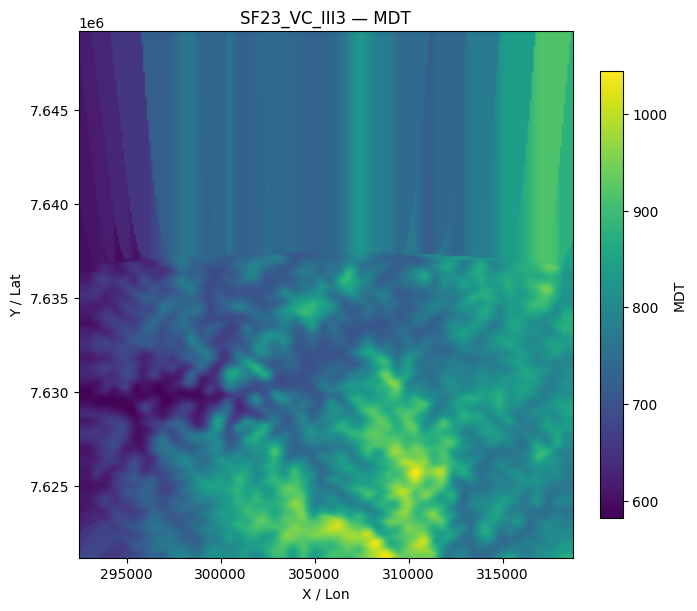

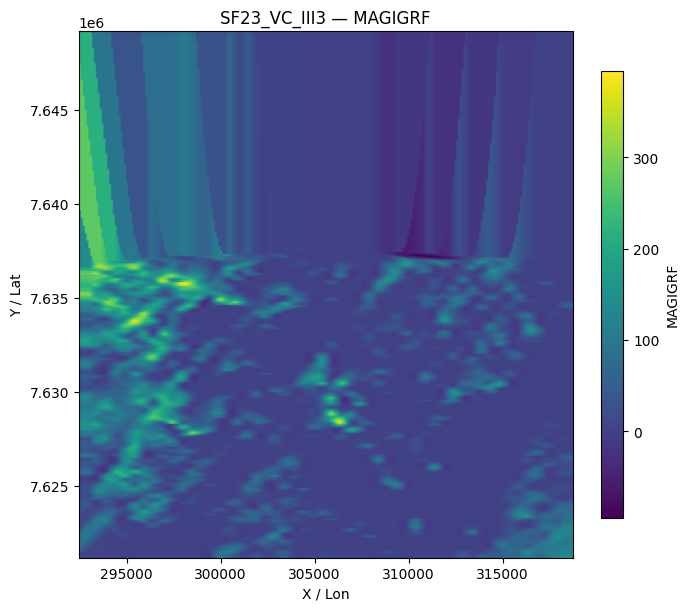

In [43]:
plot_interp(fid, "MDT")
plot_interp(fid, "MAGIGRF")


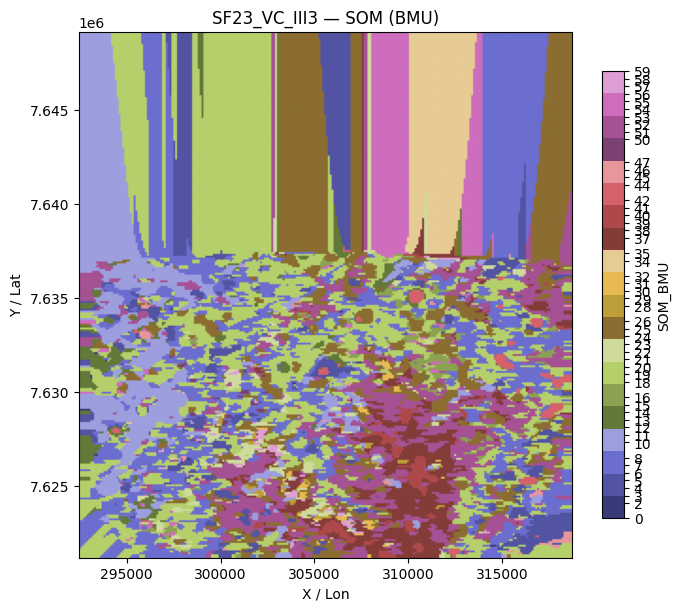

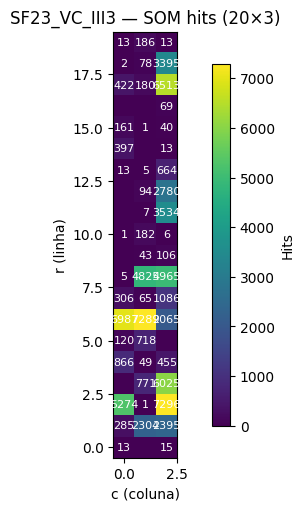

In [44]:
plot_som_labels(fid)
plot_som_hits(fid)  # usa m,n do CFG["som"]


In [60]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from rasterio.transform import from_origin
def export_geotiff_stack(
    fid,
    features=None,
    outpath="exports/rasters_stack.tif",
    epsg=None,
    nodata=np.nan,
    dtype="float32",
):
    """
    Exporta um GeoTIFF multibanda com as camadas interpoladas de uma folha.
    - Requer que o grid seja regular (funciona via pivot -> imshow).
    - Todas as bands devem compartilhar a mesma malha (mesmo shape/extent).
    """
    df = STATE["quadricula"][fid][STATE["interp_key"]]

    # 1) Seleção de features numéricas úteis
    if features is None:
        skip = {"som_bmu", "geometry"}
        numcols = [
            c for c in df.columns
            if c.lower() not in skip and pd.api.types.is_numeric_dtype(df[c])
        ]
        features = [
            c for c in numcols
            if c.lower() not in {
                "x", "y", "lon", "long", "longitude",
                "lat", "latitude", "utme", "utmn",
                "easting", "northing", "row", "col"
            }
        ]

    if not features:
        raise ValueError("Nenhuma feature numérica elegível encontrada para exportar.")

    # 2) Grid base (define geometria e perfil)
    first_img = _to_image(df, features[0])
    if first_img is None:
        raise ValueError("Grid não é regular; use export_geopackage_points() como fallback.")
    arr0, extent = first_img
    if arr0 is None or arr0.ndim != 2:
        raise ValueError("Grid base inválido (esperado array 2D).")

    xmin, xmax, ymin, ymax = extent
    ny, nx = arr0.shape
    xres = (xmax - xmin) / nx
    yres = (ymax - ymin) / ny
    transform = from_origin(xmin, ymax, xres, yres)

    # 3) Detecta EPSG (prioriza parâmetro; senão, meta['epsg'] ou folha.crs)
    meta = STATE["quadricula"][fid]
    crs_epsg = None
    if epsg is not None:
        crs_epsg = int(str(epsg).split(":")[-1])
    elif meta.get("epsg"):
        crs_epsg = int(str(meta["epsg"]).split(":")[-1])
    else:
        folha = meta.get("folha")
        crs = getattr(folha, "crs", None)
        if crs is not None:
            try:
                e = crs.to_epsg()
                if e:
                    crs_epsg = int(e)
            except Exception:
                pass
    if not crs_epsg:
        raise ValueError(
            "EPSG não informado e não foi possível detectar do meta/folha.\n"
            "→ Soluções: passe epsg=32723 (por exemplo) ou garanta que meta['epsg'] ou folha.crs estejam definidos."
        )

    # 4) Garante dtype e trata nodata
    np_dtype = np.dtype(dtype).name  # normaliza string -> dtype válido
    is_float = np.issubdtype(np.dtype(np_dtype), np.floating)
    if not is_float and (isinstance(nodata, float) and np.isnan(nodata)):
        # nodata NaN só faz sentido para rasters float
        nodata = 0

    # 5) Garante diretório de saída
    outdir = os.path.dirname(outpath)
    if outdir:
        os.makedirs(outdir, exist_ok=True)

    profile = {
        "driver": "GTiff",
        "height": ny,
        "width": nx,
        "count": len(features),
        "dtype": np_dtype,
        "crs": f"EPSG:{int(crs_epsg)}",
        "transform": transform,
        "nodata": nodata,
        "tiled": True,
        "compress": "LZW",
    }

    # 6) Escreve banda a banda, checando consistência de grade
    with rasterio.open(outpath, "w", **profile) as dst:
        for i, feat in enumerate(features, start=1):
            img = _to_image(df, feat)
            if img is None:
                raise ValueError(
                    f"A feature '{feat}' não está em grade regular como a primeira; "
                    "use export_geopackage_points() ou reamostre as camadas."
                )
            arr, ext = img
            if arr.shape != (ny, nx) or tuple(ext) != tuple(extent):
                raise ValueError(
                    f"'{feat}' tem shape/extent diferentes da grade base: "
                    f"esperado {arr0.shape} @ {extent}, obtido {arr.shape} @ {ext}."
                )
            # Flip vertical para origem no canto superior esquerdo (GeoTIFF)
            band = np.flipud(arr).astype(np_dtype, copy=False)
            # Substitui +-inf por nodata
            if np.isinf(band).any():
                band = band.copy()
                band[~np.isfinite(band)] = nodata
            dst.write(band, i)
            dst.set_band_description(i, feat)

    return outpath


In [61]:
stack = export_geotiff_stack(fid, outpath=f"out_tif/{fid}_stack.tif")
a

ValueError: EPSG não informado e não foi possível detectar do meta/folha.
→ Soluções: passe epsg=32723 (por exemplo) ou garanta que meta['epsg'] ou folha.crs estejam definidos.

In [62]:
import re

def _detect_epsg_from_meta(fid):
    meta = STATE["quadricula"][fid]

    # 1) meta['epsg'] direto (int, 'EPSG:####' ou similar)
    eps = meta.get("epsg")
    if eps:
        try:
            return int(str(eps).split(":")[-1])
        except Exception:
            pass

    # 2) CRS da 'folha' (GeoDataFrame/GeoSeries)
    folha = meta.get("folha")
    crs = getattr(folha, "crs", None)
    if crs is not None:
        try:
            eps = crs.to_epsg()  # retorna int se possível
            if eps:
                return int(eps)
        except Exception:
            s = str(crs)
            m = re.search(r"EPSG[:= ]\s*(\d+)", s, flags=re.I)
            if m:
                return int(m.group(1))

    # 3) (opcional) outras chaves que você use, como 'gdf'
    gdf = meta.get("gdf")
    crs = getattr(gdf, "crs", None)
    if crs is not None:
        try:
            eps = crs.to_epsg()
            if eps:
                return int(eps)
        except Exception:
            s = str(crs)
            m = re.search(r"EPSG[:= ]\s*(\d+)", s, flags=re.I)
            if m:
                return int(m.group(1))

    return None


In [63]:
fid = next(iter(STATE["quadricula"].keys()))
print("EPSG detectado:", _detect_epsg_from_meta(fid))

EPSG detectado: None


In [64]:
stack = export_geotiff_stack(fid, outpath=f"out_tif/{fid}_stack.tif")


ValueError: EPSG não informado e não foi possível detectar do meta/folha.
→ Soluções: passe epsg=32723 (por exemplo) ou garanta que meta['epsg'] ou folha.crs estejam definidos.

In [69]:
def set_epsg(fid, epsg):
    eps = int(str(epsg).split(":")[-1])
    meta = STATE["quadricula"][fid]
    meta["epsg"] = eps
    # se a folha existir sem CRS, seta também (não reprojeta, só define)
    folha = meta.get("folha")
    if hasattr(folha, "crs") and getattr(folha, "crs", None) is None and hasattr(folha, "set_crs"):
        meta["folha"] = folha.set_crs(f"EPSG:{eps}")

# exemplo:
set_epsg(fid, 31983)
stack = export_geotiff_stack(fid, outpath=f"out_tif/{fid}_stack.tif")


In [65]:
import re
import numpy as np

def _guess_zone_from_fid(fid: str):
    # tenta capturar um número de 2 dígitos típico dos códigos (18..25 no Brasil)
    m = re.search(r'(\d{2})', fid)
    if not m:
        return None
    z = int(m.group(1))
    return z if 18 <= z <= 25 else None

def _epsg_sirgas_sul(zone: int) -> int:
    # SIRGAS 2000 / UTM South: 31960 + zone (ex.: 23S → 31983)
    return 31960 + int(zone)

def _detect_epsg_from_meta(fid):
    meta = STATE["quadricula"][fid]

    # 1) já definido
    if meta.get("epsg"):
        try:
            return int(str(meta["epsg"]).split(":")[-1])
        except Exception:
            pass

    # 2) CRS da folha
    folha = meta.get("folha")
    crs = getattr(folha, "crs", None)
    if crs is not None:
        try:
            e = crs.to_epsg()
            if e:
                return int(e)
        except Exception:
            s = str(crs)
            m = re.search(r"EPSG[:= ]\s*(\d+)", s, flags=re.I)
            if m:
                return int(m.group(1))

    # 3) Heurística por código da folha (ex.: "SF23" → 23S)
    z = _guess_zone_from_fid(fid)
    if z:
        return _epsg_sirgas_sul(z)

    # 4) Último recurso: tentar inferir se coords parecem graus e estimar zona
    df = STATE["quadricula"][fid][STATE["interp_key"]]
    lowers = {c.lower(): c for c in df.columns}
    X = df.get(lowers.get("x")) or df.get(lowers.get("lon")) or df.get(lowers.get("longitude"))
    Y = df.get(lowers.get("y")) or df.get(lowers.get("lat")) or df.get(lowers.get("latitude"))
    if X is not None and Y is not None:
        xmn, xmx = float(np.nanmin(X)), float(np.nanmax(X))
        ymn, ymx = float(np.nanmin(Y)), float(np.nanmax(Y))
        if -180 <= xmn <= 180 and -180 <= xmx <= 180 and -90 <= ymn <= 90 and -90 <= ymx <= 90:
            # Parece graus: use EPSG:4326 (só rotula, não reprojeta)
            return 4326

    return None


In [67]:
fid

'SF23_VC_III3'

In [66]:
df = STATE["quadricula"][fid][STATE["interp_key"]]
print(df[["X","Y"]].describe())  # ajuste os nomes se forem diferentes


                   X             Y
count   73098.000000  7.309800e+04
mean   305587.791052  7.635184e+06
std      7608.851372  8.109018e+03
min    292459.169272  7.621189e+06
25%    298998.329545  7.628136e+06
50%    305587.791052  7.635184e+06
75%    312177.252558  7.642231e+06
max    318716.412831  7.649178e+06


In [70]:
eps = _detect_epsg_from_meta(fid)
print("EPSG auto:", eps)
if eps:
    set_epsg(fid, eps)
    stack = export_geotiff_stack(fid, outpath=f"out_tif/{fid}_stack.tif")
else:
    # se ainda não deu, escolha manualmente a zona mais provável:
    stack = export_geotiff_stack(fid, outpath=f"out_tif/{fid}_stack.tif", epsg=31983)


EPSG auto: 31983


In [71]:
import os
import pandas as pd

OUT_ROOT = "out_tif"
DEFAULT_EPSG = None  # ex.: 31983 (SIRGAS 2000 / UTM 23S). Deixe None para tentar auto/meta.

for fid, meta in STATE["quadricula"].items():
    # precisa ter grid interpolado
    if STATE.get("interp_key") not in meta or meta[STATE["interp_key"]].empty:
        print(f"[{fid}] sem grid interpolado — pulando.")
        continue

    df = meta[STATE["interp_key"]]

    # escolhe features numéricas úteis (todas as camadas do grid)
    skip = {"som_bmu", "geometry"}
    numcols = [c for c in df.columns if c.lower() not in skip and pd.api.types.is_numeric_dtype(df[c])]
    features = [
        c for c in numcols
        if c.lower() not in {
            "x","y","lon","long","longitude","lat","latitude",
            "utme","utmn","easting","northing","row","col"
        }
    ]
    if not features:
        print(f"[{fid}] sem features numéricas para stack — pulando.")
        continue

    # define EPSG: DEFAULT -> _detect_epsg_from_meta -> meta['epsg']
    eps = DEFAULT_EPSG
    if eps is None:
        try:
            eps = _detect_epsg_from_meta(fid)  # se você colou o helper; senão, ignora
        except NameError:
            eps = None
    if eps is None:
        eps = meta.get("epsg")

    if eps is None:
        print(f"[{fid}] EPSG indefinido (DEFAULT_EPSG/_detect_epsg_from_meta/meta['epsg']). "
              f"Defina DEFAULT_EPSG ou meta['epsg'] e rode de novo. Pulando.")
        continue

    # salva um TIF por folha com todas as camadas (stack multibanda)
    outdir = f"{OUT_ROOT}/{fid}"
    os.makedirs(outdir, exist_ok=True)
    outpath = f"{outdir}/{fid}_stack.tif"

    try:
        stack_path = export_geotiff_stack(
            fid,
            features=features,
            outpath=outpath,
            epsg=int(str(eps).split(":")[-1])  # aceita 31983 ou "EPSG:31983"
        )
        print(f"[{fid}] ✓ stack salvo → {stack_path}")
    except Exception as e:
        print(f"[{fid}] ✗ erro no stack: {e} (se grid não for regular, use export_geopackage_points)")


[SF23_VC_III3] ✓ stack salvo → out_tif/SF23_VC_III3/SF23_VC_III3_stack.tif
[SF23_VC_VI1] ✓ stack salvo → out_tif/SF23_VC_VI1/SF23_VC_VI1_stack.tif
[SF23_VC_VI3] ✓ stack salvo → out_tif/SF23_VC_VI3/SF23_VC_VI3_stack.tif
[SF23_YA_III1] sem grid interpolado — pulando.
[SF23_YA_III3] sem grid interpolado — pulando.
[SF23_VC_III4] ✓ stack salvo → out_tif/SF23_VC_III4/SF23_VC_III4_stack.tif
[SF23_VC_VI2] ✓ stack salvo → out_tif/SF23_VC_VI2/SF23_VC_VI2_stack.tif
[SF23_VC_VI4] ✓ stack salvo → out_tif/SF23_VC_VI4/SF23_VC_VI4_stack.tif
[SF23_YA_III2] ✓ stack salvo → out_tif/SF23_YA_III2/SF23_YA_III2_stack.tif
[SF23_YA_III4] ✓ stack salvo → out_tif/SF23_YA_III4/SF23_YA_III4_stack.tif
[SF23_VD_I3] sem grid interpolado — pulando.
[SF23_VD_IV3] sem grid interpolado — pulando.
[SF23_YB_I1] ✓ stack salvo → out_tif/SF23_YB_I1/SF23_YB_I1_stack.tif
[SF23_YB_I3] ✓ stack salvo → out_tif/SF23_YB_I3/SF23_YB_I3_stack.tif
[SF23_YB_IV1] ✓ stack salvo → out_tif/SF23_YB_IV1/SF23_YB_IV1_stack.tif
[SF23_YB_IV3] ✓ s